In [1]:
%matplotlib inline
import os

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.io import loadmat

sns.set_style("whitegrid")

In [2]:
in_dir = "simulations/static"
data = np.loadtxt(os.path.join(in_dir, "data.txt"))
weights = np.loadtxt(os.path.join(in_dir, "weights.txt"))
components = np.loadtxt(os.path.join(in_dir, "components.txt"))
n_volumes = components.shape[1]
n_voxels, n_signals = weights.shape

In [3]:
results = loadmat(os.path.join(in_dir, "cpca.mat"))
cpca_components = results["Va"].T.real
cpca_weights = np.abs(results["U"])
cpca_delays = np.angle(results["U"])

In [4]:
corrs = np.corrcoef(np.vstack((components, cpca_components.T)))
corrs = corrs[:n_signals, n_signals:]
print(np.round(corrs, 3))

[[-0.129 -0.986  0.203]
 [ 0.981  0.062 -0.071]
 [-0.015 -0.142 -0.965]]


In [5]:
corrs = np.corrcoef(np.hstack((weights, cpca_weights)).T)
corrs = corrs[:n_signals, n_signals:]
print(np.round(corrs, 3))

[[-0.06  -0.01  -0.028]
 [ 0.026  0.026  0.04 ]
 [-0.019  0.052 -0.067]]


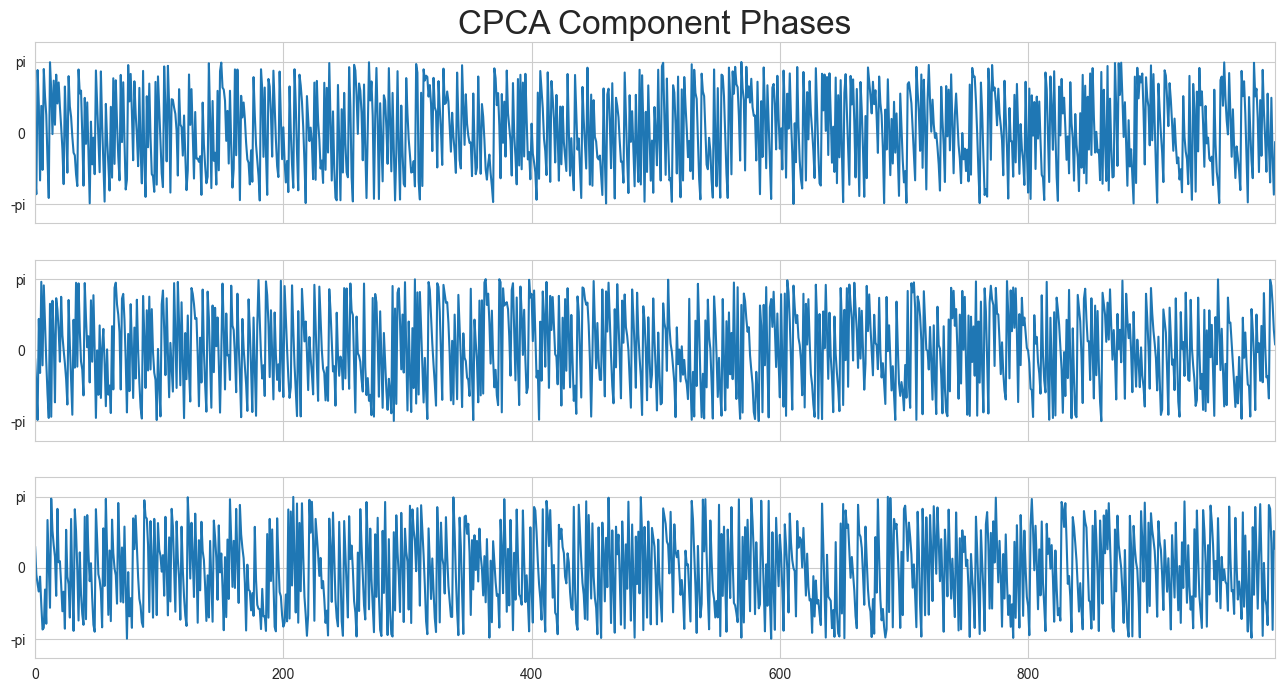

In [6]:
fig, axes = plt.subplots(figsize=(16, 8), nrows=3, sharex=True, sharey=True)
for i_signal in range(n_signals):
    axes[i_signal].plot(cpca_delays[:, i_signal])

axes[0].set_xlim(0, n_voxels - 1)
axes[0].set_yticks([-np.pi, 0, np.pi])
axes[0].set_yticklabels(["-pi", "0", "pi"])
axes[0].set_ylim(-4, 4)
axes[0].set_title("CPCA Component Phases", fontsize=24)
fig.savefig(os.path.join(in_dir, "cpca_delays.png"))

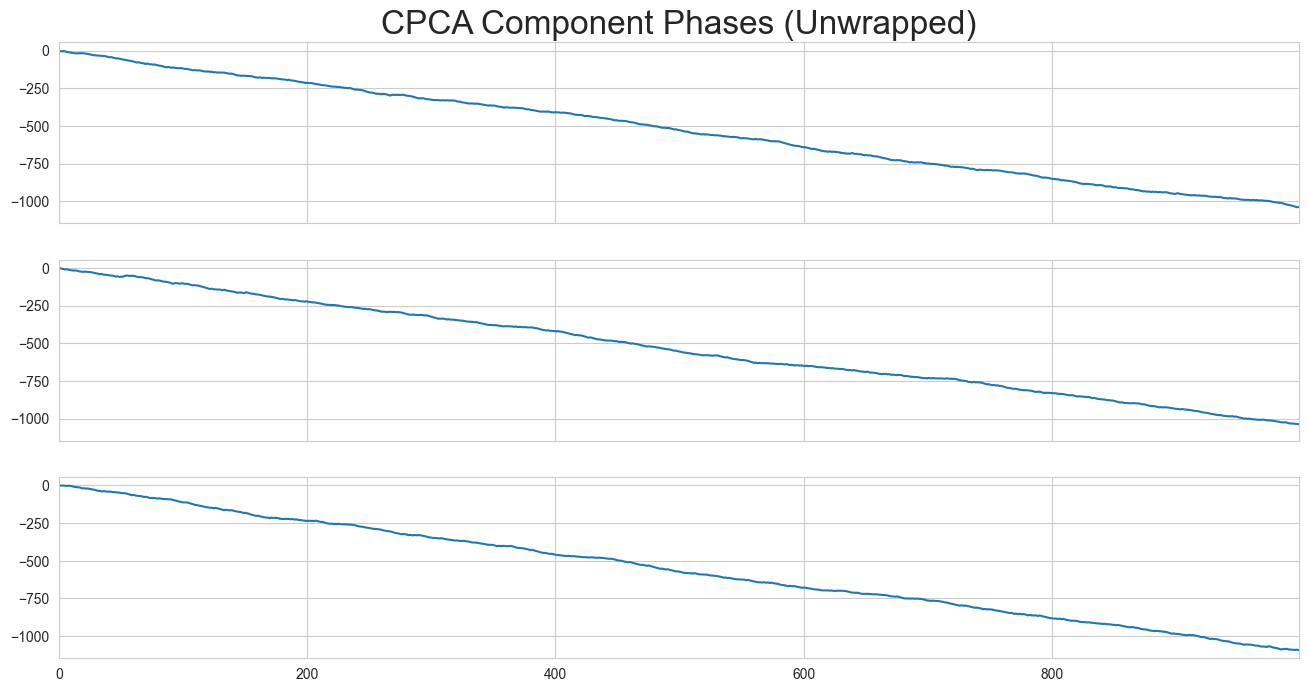

In [7]:
fig, axes = plt.subplots(figsize=(16, 8), nrows=3, sharex=True, sharey=True)
for i_signal in range(n_signals):
    axes[i_signal].plot(np.unwrap(cpca_delays[:, i_signal]))

axes[0].set_xlim(0, n_voxels - 1)
axes[0].set_title("CPCA Component Phases (Unwrapped)", fontsize=24)
fig.savefig(os.path.join(in_dir, "cpca_delays_unwrapped.png"))

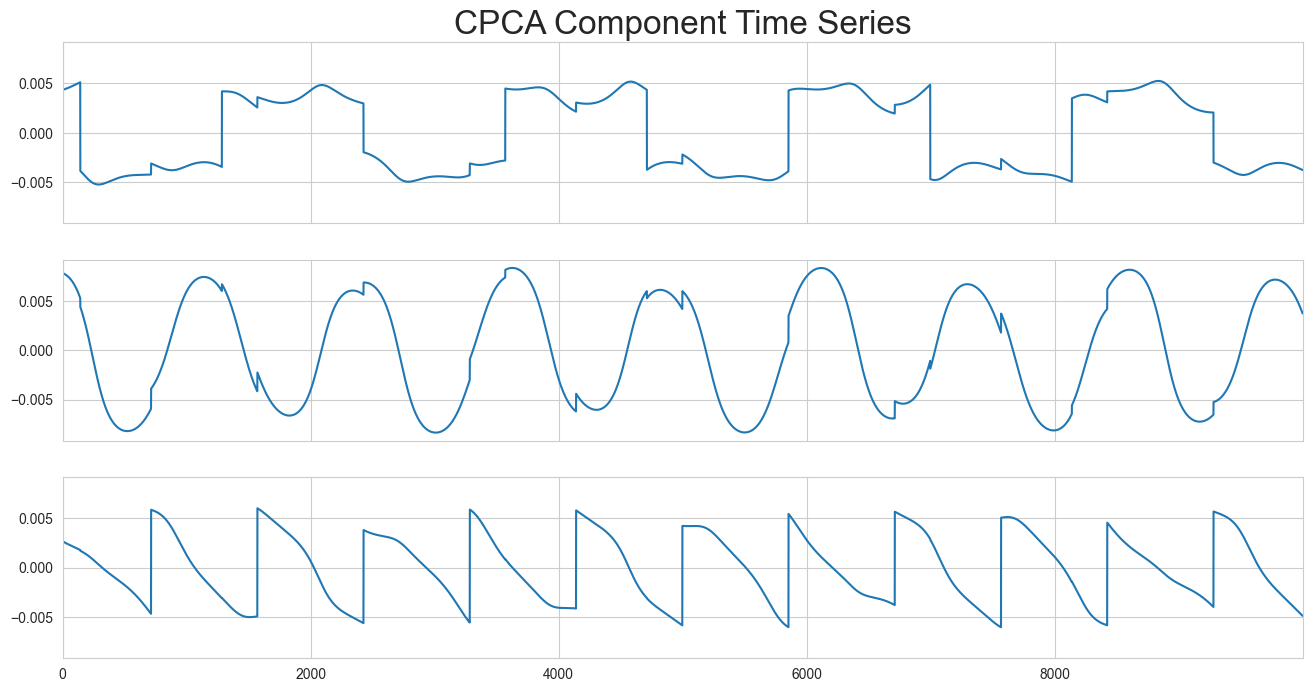

In [8]:
fig, axes = plt.subplots(figsize=(16, 8), nrows=3, sharex=True, sharey=True)
axes[0].set_title("CPCA Component Time Series", fontsize=24)
for i_signal in range(n_signals):
    axes[i_signal].plot(cpca_components[:, i_signal])

axes[0].set_xlim(0, n_volumes - 1)
fig.savefig(os.path.join(in_dir, "cpca_components.png"))

In [9]:
results = loadmat(os.path.join(in_dir, "rpca.mat"))
rpca_components = results["Va"].T.real
rpca_weights = np.abs(results["U"])
rpca_delays = np.angle(results["U"])

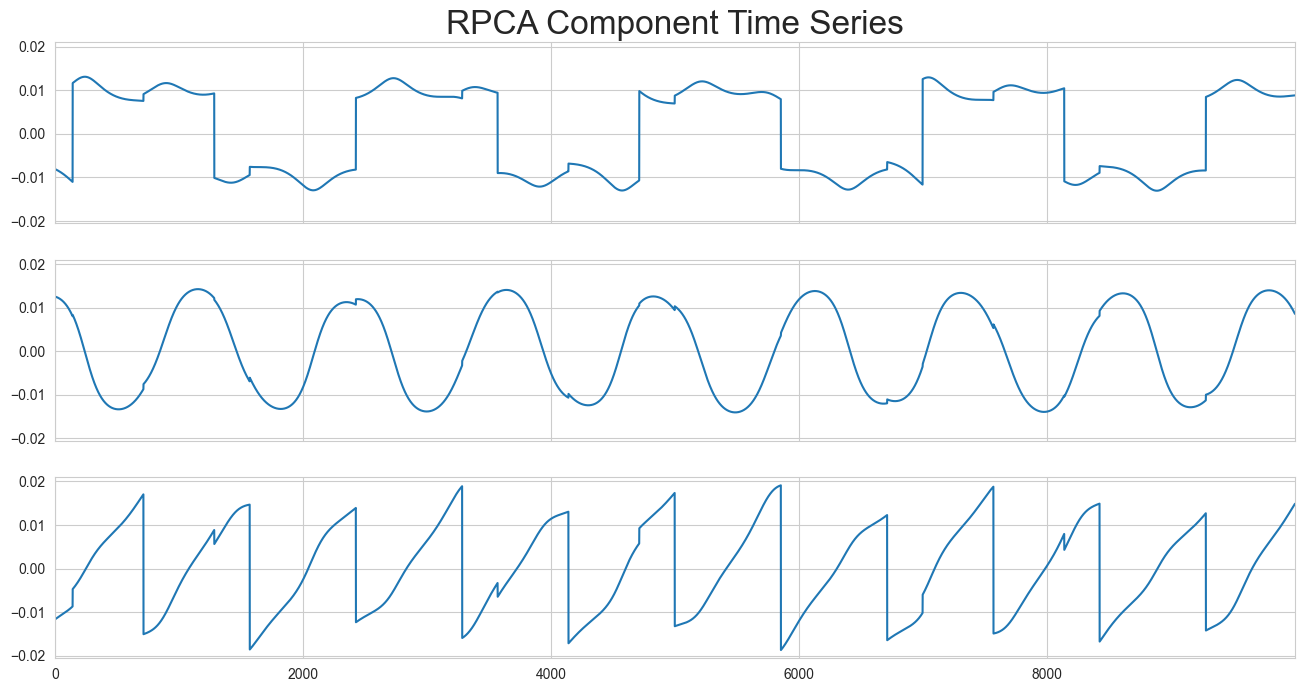

In [10]:
fig, axes = plt.subplots(figsize=(16, 8), nrows=3, sharex=True, sharey=True)
axes[0].set_title("RPCA Component Time Series", fontsize=24)
for i_signal in range(n_signals):
    axes[i_signal].plot(rpca_components[:, i_signal])

axes[0].set_xlim(0, n_volumes - 1)
fig.savefig(os.path.join(in_dir, "rpca_components.png"))